In [6]:
import numpy as np
import astropy.io.fits as fits
from astropy.table import Table
import matplotlib.pyplot as plt
from astropy.coordinates import SkyCoord
import astropy.units as u
from astropy.nddata import Cutout2D, NoOverlapError, NDData
from astropy.visualization import ZScaleInterval
from astropy import wcs, table
from astropy.wcs import WCS
import matplotlib.patches as mpatches
from astropy.wcs.utils import proj_plane_pixel_scales
from scipy.spatial import cKDTree
from shapely.geometry import Point
from shapely.affinity import scale, rotate
import warnings
from astropy.io.fits.verify import VerifyWarning
from astropy.wcs import FITSFixedWarning
warnings.simplefilter('ignore', category=FITSFixedWarning)

def add_seg_ellip(ax, pos, a, b, theta, frame_wcs, **kwargs):
    """
    Add an ellipse to the given axis.

    Parameters:
    - ax: The matplotlib axis to add the ellipse to.
    - pos: the SkyCoord position of the center of the ellipse.
    - a: Semi-major axis length.
    - b: Semi-minor axis length.
    - theta: Position angle in degrees (counter-clockwise from the x-axis).
    - kwargs: Additional keyword arguments for styling the ellipse (e.g., edgecolor, facecolor).
    """
    # Create the ellipse patch
    x, y = frame_wcs.all_world2pix(pos.ra, pos.dec, 0)
    pixscale = proj_plane_pixel_scales(frame_wcs)[0]*3600  # Assuming square pixels
    ellipse = mpatches.Ellipse(xy=(x, y), 
                               width=2*a/pixscale, 
                               height=2*b/pixscale, 
                               angle=theta, 
                               transform = ax.get_transform("pixel"),
                               **kwargs)

    # Add the ellipse to the axis
    ax.add_patch(ellipse)

def radec_to_cartesian(ra_deg, dec_deg):
    """Convert RA/Dec to unit-sphere 3D cartesian — handles wrap-around correctly."""
    ra  = np.radians(ra_deg)
    dec = np.radians(dec_deg)
    x = np.cos(dec) * np.cos(ra)
    y = np.cos(dec) * np.sin(ra)
    z = np.sin(dec)
    return np.stack([x, y, z], axis=1)   # shape (N, 3)

def chord_to_arcsec(chord):
    """Convert 3D chord distance to great-circle separation in arcsec."""
    # chord = 2 * sin(theta/2)  →  theta = 2 * arcsin(chord/2)
    return np.degrees(2 * np.arcsin(np.clip(chord / 2, -1, 1))) * 3600


def make_ellipse_sky(center, A_arcsec, B_arcsec, theta_deg, ref):
    """
    Build a shapely ellipse in an offset (arcsec) frame centered on ref.
    center  : SkyCoord of the ellipse center
    ref     : SkyCoord origin of the local tangent plane
    Returns a shapely Polygon.
    """
    # Project center onto tangent plane (arcsec) relative to ref
    dra  = (center.ra  - ref.ra ).deg  * 3600 * np.cos(np.radians(ref.dec.deg))
    ddec = (center.dec - ref.dec).deg  * 3600

    circle  = Point(dra, ddec).buffer(1.0)
    ellipse = scale(circle, A_arcsec, B_arcsec)
    ellipse = rotate(ellipse, theta_deg, origin=(dra, ddec))
    return ellipse


def ellipses_overlap(p1, A1, B1, theta1,
                     p2, A2, B2, theta2):
    """
    Check if two sky ellipses overlap.

    Parameters (1 for target, 2 for neighbor)
    ----------
    p1, p2       : SkyCoord   — centers of the two galaxies
    A1, B1       : float      — semimajor/minor axes of galaxy 1 in arcsec
    A2, B2       : float      — semimajor/minor axes of galaxy 2 in arcsec
    theta1, theta2 : float    — position angles in degrees (CCW from x-axis)

    Returns
    -------
    bool — True if the ellipses overlap, False otherwise
    """
    # Use midpoint as tangent plane origin to minimise projection distortion
    ref = SkyCoord(
        ra  = (p1.ra.deg  + p2.ra.deg ) / 2 * u.deg,
        dec = (p1.dec.deg + p2.dec.deg) / 2 * u.deg,
    )

    e_target = make_ellipse_sky(p1, A1, B1, theta1, ref)
    e_neighbor = make_ellipse_sky(p2, A2, B2, theta2, ref)

    return (e_neighbor.intersects(e_target) or e_neighbor.contains(e_target) or e_target.contains(e_neighbor))

# Catalog Adjustment

Fengwu's original catalog may contain duplicated sources and the RA and DEC may be slightly off (because Fengwu's catalog was using a preliminary version of JADES catalog). The OBJID may also be wrong. We cross-match Fengwu's catalog with the final JADES DR2 and DR3 catalog to remove duplicated sources, correct RA and DEC, and get the correct OBJID. 

In [7]:
# note that JADES catalog has multiple extensions
JADES_GDS_FLAG = Table().read("/xdisk/timeifler/jiachuanxu/jwst/jades/catalogs/hlsp_jades_jwst_nircam_goods-s_photometry_v5.0_catalog.fits", hdu=2)
JADES_GDS_SIZE = Table().read("/xdisk/timeifler/jiachuanxu/jwst/jades/catalogs/hlsp_jades_jwst_nircam_goods-s_photometry_v5.0_catalog.fits", hdu=3)
JADES_GDS_CIRC = Table().read("/xdisk/timeifler/jiachuanxu/jwst/jades/catalogs/hlsp_jades_jwst_nircam_goods-s_photometry_v5.0_catalog.fits", hdu=4)
JADES_GDS_KRON = Table().read("/xdisk/timeifler/jiachuanxu/jwst/jades/catalogs/hlsp_jades_jwst_nircam_goods-s_photometry_v5.0_catalog.fits", hdu=8)

JADES_GDN_FLAG = Table().read("/xdisk/timeifler/jiachuanxu/jwst/jades/catalogs/hlsp_jades_jwst_nircam_goods-n_photometry_v5.0_catalog.fits", hdu=2)
JADES_GDN_SIZE = Table().read("/xdisk/timeifler/jiachuanxu/jwst/jades/catalogs/hlsp_jades_jwst_nircam_goods-n_photometry_v5.0_catalog.fits", hdu=3)
JADES_GDN_CIRC = Table().read("/xdisk/timeifler/jiachuanxu/jwst/jades/catalogs/hlsp_jades_jwst_nircam_goods-n_photometry_v5.0_catalog.fits", hdu=4)
JADES_GDN_KRON = Table().read("/xdisk/timeifler/jiachuanxu/jwst/jades/catalogs/hlsp_jades_jwst_nircam_goods-n_photometry_v5.0_catalog.fits", hdu=8)

FRESCO_GDN_cat = Table().read("/xdisk/timeifler/jiachuanxu/jwst/fengwu_catalog/v091_gdn_fresco_line_list_low-ground-z_Pa_Br.fits")
FRESCO_GDS_cat = Table().read("/xdisk/timeifler/jiachuanxu/jwst/fengwu_catalog/v094_gds_fresco_line_list_low-ground-z_Pa_Br.fits")
### CONGRESS (GO 3577) is in F356W 
CONGRESS_GDN_cat = Table().read("/xdisk/timeifler/jiachuanxu/jwst/fengwu_catalog/v091_gdn_congress_line_list_v2_low-ground-z_Pa_Br.fits")

In [8]:
MAX_SEP_ARCSEC = 1.0  # maximum separation for a match in arcseconds
# match JADES and Fengwu's catalog by RA and DEC
coord_jades_gdn = SkyCoord(ra=JADES_GDN_SIZE["RA"], dec=JADES_GDN_SIZE["DEC"])
coord_jades_gds = SkyCoord(ra=JADES_GDS_SIZE["RA"], dec=JADES_GDS_SIZE["DEC"])
coord_fresco_gdn = SkyCoord(ra=FRESCO_GDN_cat["RA"]*u.degree, dec=FRESCO_GDN_cat["DEC"]*u.degree)
coord_fresco_gds = SkyCoord(ra=FRESCO_GDS_cat["RA"]*u.degree, dec=FRESCO_GDS_cat["DEC"]*u.degree)
coord_congress_gdn = SkyCoord(ra=CONGRESS_GDN_cat["RA"]*u.degree, dec=CONGRESS_GDN_cat["DEC"]*u.degree)

fresco_gdn_idx_jades, fresco_gdn_d2d_jades, fresco_gdn_d3d_jades = coord_fresco_gdn.match_to_catalog_sky(coord_jades_gdn)
fresco_gds_idx_jades, fresco_gds_d2d_jades, fresco_gds_d3d_jades = coord_fresco_gds.match_to_catalog_sky(coord_jades_gds)
congress_gdn_idx_jades, congress_gdn_d2d_jades, congress_gdn_d3d_jades = coord_congress_gdn.match_to_catalog_sky(coord_jades_gdn)

print("====== FRESCO GDN ====")
print(f"Number of matches: {np.sum(fresco_gdn_d2d_jades.arcsec < MAX_SEP_ARCSEC)} out of {len(fresco_gdn_d2d_jades)}")
print(f"Median separation: {np.median(fresco_gdn_d2d_jades.arcsec):.3f} arcsec")
print(f"Mean separation: {np.mean(fresco_gdn_d2d_jades.arcsec):.3f} arcsec")
print(f"Max separation: {np.max(fresco_gdn_d2d_jades.arcsec):.3f} arcsec")
print("====== FRESCO GDS ====")
print(f"Number of matches: {np.sum(fresco_gds_d2d_jades.arcsec < MAX_SEP_ARCSEC)} out of {len(fresco_gds_d2d_jades)}")
print(f"Median separation: {np.median(fresco_gds_d2d_jades.arcsec):.3f} arcsec")
print(f"Mean separation: {np.mean(fresco_gds_d2d_jades.arcsec):.3f} arcsec")
print(f"Max separation: {np.max(fresco_gds_d2d_jades.arcsec):.3f} arcsec")
print("====== CONGRESS GDN ====")
print(f"Number of matches: {np.sum(congress_gdn_d2d_jades.arcsec < MAX_SEP_ARCSEC)} out of {len(congress_gdn_d2d_jades)}")
print(f"Median separation: {np.median(congress_gdn_d2d_jades.arcsec):.3f} arcsec")
print(f"Mean separation: {np.mean(congress_gdn_d2d_jades.arcsec):.3f} arcsec")
print(f"Max separation: {np.max(congress_gdn_d2d_jades.arcsec):.3f} arcsec")


====== FRESCO GDN ====
Number of matches: 260 out of 260
Median separation: 0.034 arcsec
Mean separation: 0.044 arcsec
Max separation: 0.464 arcsec
====== FRESCO GDS ====
Number of matches: 291 out of 296
Median separation: 0.019 arcsec
Mean separation: 0.089 arcsec
Max separation: 3.099 arcsec
====== CONGRESS GDN ====
Number of matches: 344 out of 345
Median separation: 0.033 arcsec
Mean separation: 0.048 arcsec
Max separation: 2.258 arcsec


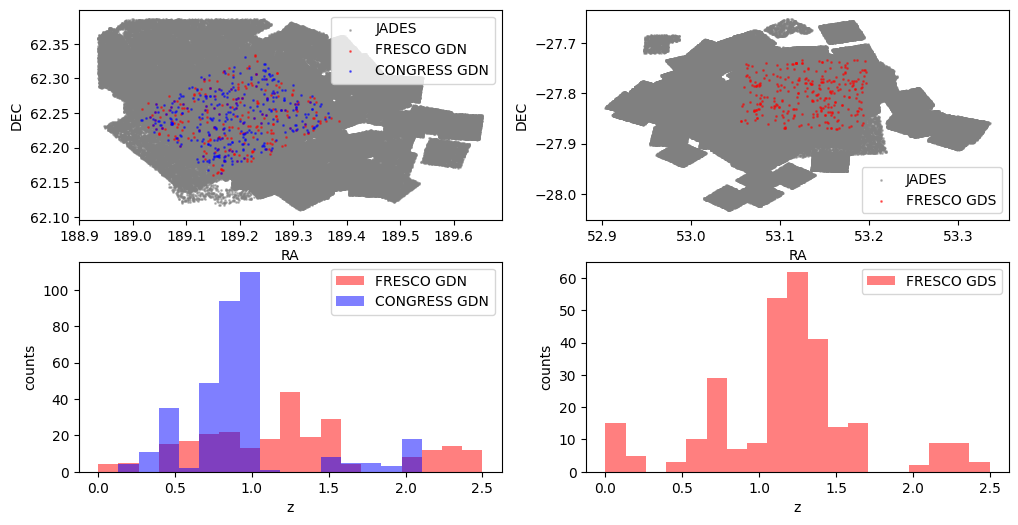

In [30]:
### Plot the positions of JADES and FRESCO GDS to visually inspect the matching
fig, axes = plt.subplots(2, 2, figsize=(12, 6))

axes[0, 0].scatter(JADES_GDN_SIZE["RA"], JADES_GDN_SIZE["DEC"], s=1, color="gray", label="JADES", alpha=0.5)
axes[0, 0].scatter(FRESCO_GDN_cat["RA"], FRESCO_GDN_cat["DEC"], s=1, color="red", label="FRESCO GDN", alpha=0.5)
axes[0, 0].scatter(CONGRESS_GDN_cat["RA"], CONGRESS_GDN_cat["DEC"], s=1, color="blue", label="CONGRESS GDN", alpha=0.5)
axes[0,0].legend()
axes[0,0].set(xlabel="RA", ylabel="DEC")

axes[0,1].scatter(JADES_GDS_SIZE["RA"], JADES_GDS_SIZE["DEC"], s=1, color="gray", label="JADES", alpha=0.5)
axes[0,1].scatter(FRESCO_GDS_cat["RA"], FRESCO_GDS_cat["DEC"], s=1, color="red", label="FRESCO GDS", alpha=0.5)
axes[0,1].legend()
axes[0,1].set(xlabel="RA", ylabel="DEC")

zbins = np.linspace(0, 2.5, 20)
axes[1,0].hist(FRESCO_GDN_cat["z_spec"], label="FRESCO GDN", color="red", alpha=0.5, bins=zbins)
axes[1,0].hist(CONGRESS_GDN_cat["z_spec"], label="CONGRESS GDN", color="blue", alpha=0.5, bins=zbins)
axes[1,0].legend()
axes[1,0].set(xlabel="z", ylabel="counts")

axes[1,1].hist(FRESCO_GDS_cat["z_spec"], label="FRESCO GDS", color="red", alpha=0.5, bins=zbins)
axes[1,1].legend()
axes[1,1].set(xlabel="z", ylabel="counts")

plt.show()

We also want to look at the image of those matched objects to ensure that the RA and DEC are making sense. 

In [10]:
CUTOUT_SIZE_ARCSEC = 6.0 * u.arcsec
NEAREST_NEIGHBOR_K = 5
broadband_coadds = [
    "/xdisk/timeifler/jiachuanxu/jwst/jades/mosaics/hlsp_jades_jwst_nircam_goods-s-deep_f444w_v2.0_drz.fits",
    "/xdisk/timeifler/jiachuanxu/jwst/jades/mosaics/hlsp_jades_jwst_nircam_goods-n_f444w_v1.0_drz.fits",
    "/xdisk/timeifler/jiachuanxu/jwst/jades/mosaics/hlsp_jades_jwst_nircam_goods-n_f444w_v1.0_drz.fits",
]
xmatch_seps = [
    fresco_gds_d2d_jades, fresco_gdn_d2d_jades, congress_gdn_d2d_jades,
]
xmatch_idxs = [
    fresco_gds_idx_jades, fresco_gdn_idx_jades, congress_gdn_idx_jades,
]
JADES_FLAG_cats = [JADES_GDS_FLAG, JADES_GDN_FLAG, JADES_GDN_FLAG]
JADES_SIZE_cats = [JADES_GDS_SIZE, JADES_GDN_SIZE, JADES_GDN_SIZE]
JADES_KRON_cats = [JADES_GDS_KRON, JADES_GDN_KRON, JADES_GDN_KRON]
GRISM_cats = [FRESCO_GDS_cat, FRESCO_GDN_cat, CONGRESS_GDN_cat]
GRISM_names = ["FRESCO_GDS", "FRESCO_GDN", "CONGRESS_GDN"]
GRISM_bands = ["F444W", "F444W", "F444W"]

FLUX_RATIO_FROM_BLENDS_ALL_SAMPLES = []

#####################################################################################################################

### For each grism dataset
for sample_idx in range(3):
#for sample_idx in range(2, 3):
    band = GRISM_bands[sample_idx]
    broadband_coadd_fn = broadband_coadds[sample_idx]
    broadband_img = fits.getdata(broadband_coadd_fn, 1)
    broadband_err = fits.getdata(broadband_coadd_fn, 2)
    broadband_hdr = fits.getheader(broadband_coadd_fn, 1)

    matched = (xmatch_seps[sample_idx].arcsec < MAX_SEP_ARCSEC)

    GRISM_cat = GRISM_cats[sample_idx]
    JADES_SIZE_cat = JADES_SIZE_cats[sample_idx]
    JADES_KRON_cat = JADES_KRON_cats[sample_idx]
    JADES_FLAG_cat = JADES_FLAG_cats[sample_idx]

    ### Find k-nearest neighbors in JADES using cKDTree
    xyz_jades = radec_to_cartesian(JADES_SIZE_cat["RA"].value, JADES_SIZE_cat["DEC"].value)
    xyz_grism = radec_to_cartesian(GRISM_cat["RA"], GRISM_cat["DEC"])
    tree  = cKDTree(xyz_jades)
    distances, indices = tree.query(xyz_grism, k=NEAREST_NEIGHBOR_K+1)   # shape (N_grism, K+1)
    distances = distances[:, 1:]  # exclude the closest one (itself)
    indices = indices[:, 1:]      # shape (N_grism, K)
    # Convert chord distances to arcsec
    separations_arcsec = chord_to_arcsec(distances)

    COORD_JADES = SkyCoord(ra=JADES_SIZE_cat["RA"], dec=JADES_SIZE_cat["DEC"])
    fresco_gdn_idx_jades, fresco_gdn_d2d_jades, fresco_gdn_d3d_jades = coord_fresco_gdn.match_to_catalog_sky(COORD_JADES)

    FLUX_RATIO_FROM_BLENDS = []

    ### For each galaxy in the grism catalog
    for i in range(len(matched)):
    #for i in range(320,321):
        if not matched[i]:
            # Do nothing
            FLUX_RATIO_FROM_BLENDS.append(-99)
            continue
        else:
            GRISM_idx = i
            JADES_idx = xmatch_idxs[sample_idx][i]
            GRISM_ID = GRISM_cat["ID"][GRISM_idx]
            JADES_ID = JADES_SIZE_cat["ID"][JADES_idx]
            # get the cutout of broadband image at both Fengwu's position and JADES position for sanity check
            pos_GRISM = SkyCoord(ra=GRISM_cat["RA"][GRISM_idx], dec=GRISM_cat["DEC"][GRISM_idx], unit=(u.deg, u.deg))
            pos_JADES = SkyCoord(ra=JADES_SIZE_cat["RA"][JADES_idx], dec=JADES_SIZE_cat["DEC"][JADES_idx], unit=(u.deg, u.deg))
            try:
                cutout_GRISM = Cutout2D(broadband_img, pos_GRISM, size=CUTOUT_SIZE_ARCSEC, wcs = wcs.WCS(broadband_hdr))
                cutout_JADES = Cutout2D(broadband_img, pos_JADES, size=CUTOUT_SIZE_ARCSEC, wcs = wcs.WCS(broadband_hdr))
            except NoOverlapError or np.allclose(cutout_GRISM.data, 0.0) or np.allclose(cutout_JADES.data, 0.0):
                print(f"Object ID-{GRISM_ID} in {GRISM_names[sample_idx]} has no overlap with the broadband image.")
                exit(-1)
                _Npix = int(broadband_hdr["PIXAR_A2"]**0.5 / (CUTOUT_SIZE_ARCSEC.to(u.arcsec).value))
                cutout_GRISM = NDData(np.zeros([_Npix, _Npix]))
                cutout_JADES = NDData(np.zeros([_Npix, _Npix]))

            # plot the cutouts to visually inspect the matching
            zscale_broadband = ZScaleInterval().get_limits(cutout_GRISM.data)
            fig = plt.figure(figsize=(8, 4))

            # FRESCO/CONGRESS position
            ax1 = fig.add_subplot(1, 2, 1, projection=cutout_GRISM.wcs)
            ax1.imshow(cutout_GRISM.data, origin='lower', vmin=zscale_broadband[0], vmax=zscale_broadband[1], cmap='binary')
            ax1.autoscale(False) 
            ax1.scatter(pos_GRISM.ra, pos_GRISM.dec, marker='+', color='green', s=100, transform=ax1.get_transform('world'))
            add_seg_ellip(ax1, pos_GRISM, 
                        a=JADES_KRON_cat["A_KRON"][JADES_idx], 
                        b=JADES_KRON_cat["B_KRON"][JADES_idx], 
                        theta=JADES_KRON_cat["THETA_KRON"][JADES_idx], 
                        frame_wcs=cutout_GRISM.wcs,
                        edgecolor='green', facecolor='none',
                        )
            pos_GRISM_string = "RA ="+pos_GRISM.ra.to_string(unit=u.hour, sep=':') + \
                                "\nDEC="+pos_GRISM.dec.to_string(unit=u.degree, sep=':')
            ax1.text(0.05, 0.95, "%s\nID-%07d\n"%(GRISM_names[sample_idx], int(GRISM_ID)) + pos_GRISM_string,
                        transform=ax1.transAxes, color='k', ha='left', va='top',
                        bbox=dict(boxstyle="round,pad=0.3", edgecolor='k', facecolor='white', alpha=0.8))
            
            # JADES position
            ax2 = fig.add_subplot(1, 2, 2, projection=cutout_JADES.wcs)
            ax2.imshow(cutout_JADES.data, origin='lower', vmin=zscale_broadband[0], vmax=zscale_broadband[1], cmap='binary')
            ax2.autoscale(False) 
            ax2.scatter(pos_JADES.ra, pos_JADES.dec, marker='+', color='green', s=100, transform=ax2.get_transform('world'))
            add_seg_ellip(ax2, pos_JADES, 
                        a=JADES_KRON_cat["A_KRON"][JADES_idx], 
                        b=JADES_KRON_cat["B_KRON"][JADES_idx], 
                        theta=JADES_KRON_cat["THETA_KRON"][JADES_idx], 
                        frame_wcs=cutout_JADES.wcs,
                        edgecolor='green', facecolor='none',
                        )
            pos_JADES_string = "RA ="+pos_JADES.ra.to_string(unit=u.hour, sep=':') + \
                                "\nDEC="+pos_JADES.dec.to_string(unit=u.degree, sep=':')
            ax2.text(0.05, 0.95, "JADES DR5\nID-%07d\n"%int(JADES_ID) + pos_JADES_string,
                        transform=ax2.transAxes, color='k', ha='left', va='top',
                        bbox=dict(boxstyle="round,pad=0.3", edgecolor='k', facecolor='white', alpha=0.8))
            ax1.text(0.05, 0.05, "Separation = %.3f arcsec"%(xmatch_seps[sample_idx].arcsec[GRISM_idx]), transform=ax1.transAxes,
                        color='k', ha='left', va='bottom',
                        bbox=dict(boxstyle="round,pad=0.3", edgecolor='k', facecolor='white', alpha=0.8))

            ### Find other siblings if the object is blended (i.e., if it has a PARENT_ID in the FLAG extension)
            if JADES_FLAG_cat["PARENT_ID"][JADES_idx] != JADES_ID:
                siblings_idx = np.where(JADES_FLAG_cat["PARENT_ID"] == JADES_FLAG_cat["PARENT_ID"][JADES_idx])[0]
                for sibling_idx in siblings_idx:
                    if sibling_idx == JADES_idx:
                        continue
                    pos_sibling = SkyCoord(ra=JADES_SIZE_cat["RA"][sibling_idx], dec=JADES_SIZE_cat["DEC"][sibling_idx], unit=(u.deg, u.deg))
                    ax2.scatter(pos_sibling.ra, pos_sibling.dec, marker='x', color='yellow', s=20, transform=ax2.get_transform('world'))
                    add_seg_ellip(ax2, pos_sibling, 
                        a=JADES_KRON_cat["A_KRON"][sibling_idx], 
                        b=JADES_KRON_cat["B_KRON"][sibling_idx], 
                        theta=JADES_KRON_cat["THETA_KRON"][sibling_idx], 
                        frame_wcs=cutout_JADES.wcs,
                        edgecolor='yellow', facecolor='none', ls='--',
                        )
            ### Find the nearest k neighbor in JADES to determine blended or not 
            _BLEND_FLUX_ = 0
            for k in range(NEAREST_NEIGHBOR_K):
                neighbor_idx = indices[GRISM_idx, k]
                neighbor_sep_arcsec = separations_arcsec[GRISM_idx, k]
                #print(neighbor_sep_arcsec)
                pos_neighbor = SkyCoord(ra=JADES_SIZE_cat["RA"][neighbor_idx], dec=JADES_SIZE_cat["DEC"][neighbor_idx], unit=(u.deg, u.deg))
                overlap = ellipses_overlap(
                    p1=pos_JADES, A1=JADES_KRON_cat["A_KRON"][JADES_idx], B1=JADES_KRON_cat["B_KRON"][JADES_idx], theta1=JADES_KRON_cat["THETA_KRON"][JADES_idx],
                    p2=pos_neighbor, A2=JADES_KRON_cat["A_KRON"][neighbor_idx], B2=JADES_KRON_cat["B_KRON"][neighbor_idx], theta2=JADES_KRON_cat["THETA_KRON"][neighbor_idx],
                )
                if overlap:
                    _BLEND_FLUX_ += JADES_KRON_cat[f"{band}_KRON"][neighbor_idx]
                    ax2.scatter(pos_neighbor.ra, pos_neighbor.dec, marker='x', color='r', s=20, transform=ax2.get_transform('world'))
                    add_seg_ellip(ax2, pos_neighbor, 
                        a=JADES_KRON_cat["A_KRON"][neighbor_idx], 
                        b=JADES_KRON_cat["B_KRON"][neighbor_idx], 
                        theta=JADES_KRON_cat["THETA_KRON"][neighbor_idx], 
                        frame_wcs=cutout_JADES.wcs,
                        edgecolor='r', facecolor='none', ls='-',
                        )
            if _BLEND_FLUX_>0:
                flux_ratio = _BLEND_FLUX_/JADES_KRON_cat[f"{band}_KRON"][JADES_idx]
                ax2.text(0.95, 0.05, "Blend! (%.2f%%)" % (flux_ratio*100), transform=ax2.transAxes, color='red', ha='right', va='bottom',
                        bbox=dict(boxstyle="round,pad=0.3", edgecolor='red', facecolor='white', alpha=0.8))
                FLUX_RATIO_FROM_BLENDS.append(flux_ratio)
            else:
                ax2.text(0.95, 0.05, "Not blended", transform=ax2.transAxes, color='green', ha='right', va='bottom',
                        bbox=dict(boxstyle="round,pad=0.3", edgecolor='green', facecolor='white', alpha=0.8))
                FLUX_RATIO_FROM_BLENDS.append(0)

            ### tuning
            ax1.coords[0].set_axislabel("RA")
            ax1.coords[1].set_axislabel("Dec")
            ax2.coords[0].set_axislabel("RA")
            ax2.coords[1].set_axislabel("")
            ax2.coords[1].set_ticklabel_visible(False)
            ax1.text(0.95, 0.95, band, transform=ax1.transAxes, color='k', ha='right', va='top',
                        bbox=dict(boxstyle="round,pad=0.3", edgecolor='k', facecolor='white', alpha=0.8))
            ax2.text(0.95, 0.95, band, transform=ax2.transAxes, color='k', ha='right', va='top',
                        bbox=dict(boxstyle="round,pad=0.3", edgecolor='k', facecolor='white', alpha=0.8))

            plt.savefig("./figs/matching_%s_ID%07d.png"%(GRISM_names[sample_idx], int(GRISM_cat["ID"][GRISM_idx])))
            plt.close()
            #plt.show()
    FLUX_RATIO_FROM_BLENDS_ALL_SAMPLES.append(FLUX_RATIO_FROM_BLENDS)

In [ ]:
# for i, flux_ratio in enumerate(FLUX_RATIO_FROM_BLENDS_ALL_SAMPLES):
#     np.savetxt("flux_ratio_from_blends_sample_%d.txt" % (i), flux_ratio)

In [13]:
### Add the blend flux ratio to the grism catalogs
for i, cat in enumerate(GRISM_cats):
    fr = np.loadtxt("flux_ratio_from_blends_sample_%d.txt" % (i))
    try:
        cat.add_column(fr, name="BLEND_FLUX_RATIO")
    except ValueError:
        print(len(fr), len(cat))

260 260


Some bad matching:
- FRESCO GDS ID175448: blending matched to wrong object (JADES catalog is likely to classify the two blends as one object)
- FRESCO GDS ID188162: blending matched to wrong object (JADES catalog is likely to classify the two blends as one object) 
- FRESCO GDS ID188647: duplicate to ID188649, deblending issue
- FRESCO GDS ID191735: duplicate to ID191736, deblending issue
- FRESCO GDS ID194058: duplicate to ID194061, deblending issue
- FRESCO GDS ID195286: duplicate to ID195280, deblending issue
- FRESCO GDS ID195841: duplicate to ID195842, deblending issue
- FRESCO GDS ID265117: no object in the center

... 

There are many objects that are not matched perfectly due to deblending issue in JADES and FRESCO catalog. 

In [18]:
### Check if the matched objects have different ID
FRESCO_GDN_matched = (fresco_gdn_d2d_jades.arcsec < MAX_SEP_ARCSEC)
FRESCO_GDS_matched = (fresco_gds_d2d_jades.arcsec < MAX_SEP_ARCSEC)
CONGRESS_GDN_matched = (congress_gdn_d2d_jades.arcsec < MAX_SEP_ARCSEC)

JADESID_FRESCO_GDN = JADES_GDN_SIZE["ID"][fresco_gdn_idx_jades[FRESCO_GDN_matched]]
JADESID_FRESCO_GDS = JADES_GDS_SIZE["ID"][fresco_gds_idx_jades[FRESCO_GDS_matched]]
JADESID_CONGRESS_GDN = JADES_GDN_SIZE["ID"][congress_gdn_idx_jades[CONGRESS_GDN_matched]]

FRESCOID_FRESCO_GDN = FRESCO_GDN_cat["ID"][FRESCO_GDN_matched]
FRESCOID_FRESCO_GDS = FRESCO_GDS_cat["ID"][FRESCO_GDS_matched]
CONGRESSID_CONGRESS_GDN = CONGRESS_GDN_cat["ID"][CONGRESS_GDN_matched]

In [19]:
### FRESCO GDS has some objects that have different OBJID in JADES and Fengwu's catalog
np.all(JADESID_FRESCO_GDN == FRESCOID_FRESCO_GDN), np.all(JADESID_FRESCO_GDS == FRESCOID_FRESCO_GDS), np.all(JADESID_CONGRESS_GDN == CONGRESSID_CONGRESS_GDN)

(False, False, False)

In [20]:
### Test if has duplicated objects in the matched catalogs
Ndup_FRESCO_GDN =len(JADESID_FRESCO_GDN) - len(np.unique(JADESID_FRESCO_GDN))
Ndup_FRESCO_GDS =len(JADESID_FRESCO_GDS) - len(np.unique(JADESID_FRESCO_GDS))
Ndup_CONGRESS_GDN =len(JADESID_CONGRESS_GDN) - len(np.unique(JADESID_CONGRESS_GDN))
print(f"Number of *possible* duplicated objects in FRESCO GDN: {Ndup_FRESCO_GDN}")
print(f"Number of *possible* duplicated objects in FRESCO GDS: {Ndup_FRESCO_GDS}")
print(f"Number of *possible* duplicated objects in CONGRESS GDN: {Ndup_CONGRESS_GDN}")

### Need to further check if the duplicated objects are of different emission lines
# get the duplicated JADES IDs in FRESCO GDN
from collections import Counter

FRESCO_GDN_counter = Counter(JADESID_FRESCO_GDN)
FRESCO_GDN_duplicates = {jades_id: count for jades_id, count in FRESCO_GDN_counter.items() if count > 1}
print(f"Duplicated JADES IDs in FRESCO GDN: {FRESCO_GDN_duplicates}")
# get the corresponding FRESCO IDs and emission lines for the duplicated JADES IDs in FRESCO GDN
for jades_id in FRESCO_GDN_duplicates:
    idx = np.where(JADESID_FRESCO_GDN == jades_id)[0]
    print(f"JADES ID {jades_id} has {len(idx)} matches in FRESCO GDN:")
    for i in idx:
        fresco_id = FRESCOID_FRESCO_GDN[i]
        line_id = FRESCO_GDN_cat["name_line_exp"][FRESCO_GDN_cat["ID"] == fresco_id][0]
        z_ref = FRESCO_GDN_cat["z_spec"][FRESCO_GDN_cat["ID"] == fresco_id][0]
        print(f"  FRESCO ID: {fresco_id}, Emission Line: {line_id}, Redshift: {z_ref}")

Number of *possible* duplicated objects in FRESCO GDN: 9
Number of *possible* duplicated objects in FRESCO GDS: 10
Number of *possible* duplicated objects in CONGRESS GDN: 8
Duplicated JADES IDs in FRESCO GDN: {1030587: 2, 1033173: 2, 1076039: 2, 1080944: 2, 1083261: 2, 1086150: 2, 1088080: 2, 1091477: 2, 1095720: 2}
JADES ID 1030587 has 2 matches in FRESCO GDN:
  FRESCO ID: 1030587, Emission Line: BrB, Redshift: 0.5012
  FRESCO ID: 1030587, Emission Line: BrB, Redshift: 0.5012
JADES ID 1033173 has 2 matches in FRESCO GDN:
  FRESCO ID: 1033172, Emission Line: PaA, Redshift: 1.63
  FRESCO ID: 1033173, Emission Line: PaA, Redshift: 1.629
JADES ID 1076039 has 2 matches in FRESCO GDN:
  FRESCO ID: 1076039, Emission Line: PaA, Redshift: 1.529
  FRESCO ID: 1076039, Emission Line: PaA, Redshift: 1.529
JADES ID 1080944 has 2 matches in FRESCO GDN:
  FRESCO ID: 1080944, Emission Line: PaA, Redshift: 1.144
  FRESCO ID: 1080944, Emission Line: PaA, Redshift: 1.144
JADES ID 1083261 has 2 matches i

OK, so they are of the same emission line.

We also want to see if objects in CONGRESS catalog also show in FRESCO catalog, and if so, do they mean the same emission line

Note that since those catalogs will be used to extract 2D grism data, we will save the FRESCO and CONGRESS GDN catalog separately, eventhough they are of the same field and share many objects in common. The merge will happen **after** grism data extraction. 

In [22]:
shared_objects_count = 0
for i, JADESID in enumerate(fresco_gdn_idx_jades[FRESCO_GDN_matched]):
    if JADESID in congress_gdn_idx_jades[CONGRESS_GDN_matched]:
        j = np.where(congress_gdn_idx_jades[CONGRESS_GDN_matched] == JADESID)[0][0]
        FRESCO_emission = FRESCO_GDN_cat["name_line_exp"][FRESCO_GDN_matched][i]
        CONGRESS_emission = CONGRESS_GDN_cat["name_line_exp"][CONGRESS_GDN_matched][j]
        shared_objects_count += 1
        print(f"ID{JADESID}: FRESCO: {FRESCO_emission} | CONGRESS: {CONGRESS_emission} | {'Same ' if FRESCO_emission == CONGRESS_emission else ''}")
print(f"Total shared objects: {shared_objects_count}")

ID2025: FRESCO: PaB | CONGRESS: PaB | Same 
ID15550: FRESCO: BrB | CONGRESS: PaA | 
ID15661: FRESCO: BrB | CONGRESS: PaA | 
ID15718: FRESCO: BrB | CONGRESS: PaA | 
ID15720: FRESCO: PaA | CONGRESS: PaB | 
ID15769: FRESCO: BrG | CONGRESS: PaA | 
ID15779: FRESCO: PaA | CONGRESS: PaB | 
ID16045: FRESCO: BrB | CONGRESS: PaA | 
ID16092: FRESCO: BrB | CONGRESS: PaA | 
ID16294: FRESCO: BrB | CONGRESS: PaA | 
ID16479: FRESCO: BrB | CONGRESS: BrG | 
ID16601: FRESCO: PaA | CONGRESS: PaB | 
ID16706: FRESCO: BrB | CONGRESS: PaA | 
ID16722: FRESCO: BrB | CONGRESS: PaA | 
ID16805: FRESCO: BrG | CONGRESS: PaA | 
ID16818: FRESCO: BrB | CONGRESS: PaA | 
ID16981: FRESCO: BrB | CONGRESS: PaA | 
ID17087: FRESCO: BrB | CONGRESS: PaA | 
ID17233: FRESCO: BrB | CONGRESS: PaA | 
ID17251: FRESCO: BrB | CONGRESS: PaA | 
ID17279: FRESCO: BrB | CONGRESS: PaA | 
ID17433: FRESCO: BrB | CONGRESS: PaA | 
ID17439: FRESCO: BrB | CONGRESS: BrG | 
ID17543: FRESCO: PaB | CONGRESS: PaB | Same 
ID17647: FRESCO: BrB | CONGRESS

Now we remove the duplicated objects and set the information to the JADES DR2/DR3 version. 

In [28]:
original_cats = [FRESCO_GDS_cat, FRESCO_GDN_cat, CONGRESS_GDN_cat]
original_matched = [FRESCO_GDS_matched, FRESCO_GDN_matched, CONGRESS_GDN_matched]
matched_indices = [fresco_gds_idx_jades[FRESCO_GDS_matched], fresco_gdn_idx_jades[FRESCO_GDN_matched], congress_gdn_idx_jades[CONGRESS_GDN_matched]]
JADES_SIZE_cats = [JADES_GDS_SIZE, JADES_GDN_SIZE, JADES_GDN_SIZE]
JADES_KRON_cats = [JADES_GDS_KRON, JADES_GDN_KRON, JADES_GDN_KRON]
JADES_CIRC_cats = [JADES_GDS_CIRC, JADES_GDN_CIRC, JADES_GDN_CIRC]

write_to_cats = [
    "/xdisk/timeifler/jiachuanxu/jwst/fengwu_catalog/v1_gds_fresco_line_list_low-ground-z_Pa_Br_jades_dr5.fits",
    "/xdisk/timeifler/jiachuanxu/jwst/fengwu_catalog/v1_gdn_fresco_line_list_low-ground-z_Pa_Br_jades_dr5.fits",
    "/xdisk/timeifler/jiachuanxu/jwst/fengwu_catalog/v1_gdn_congress_line_list_low-ground-z_Pa_Br_jades_dr5.fits"
]

for i, cat in enumerate(original_cats):
    # make a copy of the original catalog to update the information
    cat_new = cat[original_matched[i]].copy()
    for col in ["ID", "RA", "DEC", "A", "B", "PA", "FWHM", "A_KRON", "B_KRON", 
                "F444W_KRON", "F444W_KRON_e", "F444W_KRON_S", "F444W_KRON_S_e",
                "F444W_CIRC2", "F444W_CIRC2_e", "F444W_CIRC2_ei",]:
        if col not in cat_new.colnames:
            cat_new[col] = np.zeros(len(cat_new))
    JADES_indices = matched_indices[i]
    assert len(cat_new) == len(JADES_indices), "Length of the new catalog should be the same as the number of matched objects"
    # update the information in the new catalog with the corresponding information in JADES catalog
    '''Update the following information:
        ID, RA, DEC, A (in pix), B, PA, FWHM, F444W_KRON, F444W_KRON_en, F444W_KRON_S, F444W_KRON_S_en,
        F444W_CIRC2, F444W_CIRC2_e, F444W_CIRC2_en, R_KRON, R_KRON_S
        See https://arxiv.org/pdf/2601.15956 appendix for catalog documentation. 
    '''
    for j, idx in enumerate(JADES_indices):
        cat_new["ID"][j] = JADES_SIZE_cats[i]["ID"][idx]
        cat_new["RA"][j] = JADES_SIZE_cats[i]["RA"][idx] # deg
        cat_new["DEC"][j] = JADES_SIZE_cats[i]["DEC"][idx] # deg
        cat_new["A"][j] = JADES_SIZE_cats[i]["A"][idx] # arcsec
        cat_new["B"][j] = JADES_SIZE_cats[i]["B"][idx] # arcsec
        cat_new["PA"][j] = JADES_SIZE_cats[i]["THETA"][idx] # degree
        cat_new["FWHM"][j] = JADES_SIZE_cats[i]["FWHM"][idx] # arcsec
        cat_new["A_KRON"][j] = JADES_KRON_cats[i]["A_KRON"][idx] # arcsec
        cat_new["B_KRON"][j] = JADES_KRON_cats[i]["B_KRON"][idx] # arcsec
        cat_new["F444W_KRON"][j] = JADES_KRON_cats[i]["F444W_KRON"][idx] # nJy
        cat_new["F444W_KRON_e"][j] = JADES_KRON_cats[i]["F444W_KRON_e"][idx] # nJy 
        cat_new["F444W_KRON_S"][j] = JADES_KRON_cats[i]["F444W_KRON_S"][idx] # nJy
        cat_new["F444W_KRON_S_e"][j] = JADES_KRON_cats[i]["F444W_KRON_S_e"][idx] # nJy
        cat_new["F444W_CIRC2"][j] = JADES_CIRC_cats[i]["F444W_CIRC2"][idx] # nJy
        cat_new["F444W_CIRC2_e"][j] = JADES_CIRC_cats[i]["F444W_CIRC2_e"][idx] # nJy
        cat_new["F444W_CIRC2_ei"][j] = JADES_CIRC_cats[i]["F444W_CIRC2_ei"][idx] # nJy
    # remove duplicated galaxies
    cat_new = table.unique(cat_new, keys="ID", silent=False, keep='first')
    print(f"Number of objects in the new catalog {i}: {len(cat_new)}")
    # save the new catalog
    cat_new.write(write_to_cats[i], format='fits', overwrite=False)

Number of objects in the new catalog 0: 281
Number of objects in the new catalog 1: 251
Number of objects in the new catalog 2: 336


In [29]:
for cat in original_cats:
    print(f"Number of objects in the original catalog: {len(cat)}")

Number of objects in the original catalog: 296
Number of objects in the original catalog: 260
Number of objects in the original catalog: 345
